# Results Analysis — DQN Trading Agent

This notebook loads real experiment outputs and produces the comparison analysis.

## Theory recap

The Bellman target for **Double DQN**:

$$y = r + \gamma \cdot (1 - \text{done}) \cdot Q_{\theta^-}\left(s', \arg\max_{a'} Q_\theta(s', a')\right)$$

The **Dueling** decomposition:

$$Q(s,a) = V(s) + \left(A(s,a) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s,a')\right)$$

The **PER** sampling probability:

$$P(i) = \frac{p_i^\alpha}{\sum_j p_j^\alpha}, \quad w_i = \left(\frac{1}{N \cdot P(i)}\right)^\beta$$

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path('../results')
BACKTEST = RESULTS / 'backtest'

def load_exp(name):
    payload = json.loads((RESULTS / f'{name}.json').read_text())
    rows = [{'condition': c['name'], **c['metrics']} for c in payload['conditions']]
    return pd.DataFrame(rows).set_index('condition')

experiments = {}
for name in ['dqn_vs_dueling', 'uniform_vs_per', 'reward_variants', 'cross_ticker', 'window_sensitivity']:
    if (RESULTS / f'{name}.json').exists():
        experiments[name] = load_exp(name)
        
print(f'Loaded {len(experiments)} experiments')
for name, df in experiments.items():
    print(f'\n=== {name} ===')
    print(df.to_string())

Loaded 5 experiments

=== dqn_vs_dueling ===
             total_return    sharpe  max_drawdown  win_rate  n_trades  final_value
condition                                                                         
vanilla_dqn     -0.133832 -1.547847     -0.191349  0.250000         8  8661.679812
dueling_dqn     -0.223049 -3.932973     -0.240893  0.357143        14  7769.513180

=== uniform_vs_per ===
                    total_return    sharpe  max_drawdown  win_rate  n_trades  final_value
condition                                                                                
uniform_replay         -0.002382 -0.105492     -0.023511  0.666667         3  9976.179935
prioritized_replay     -0.223049 -3.932973     -0.240893  0.357143        14  7769.513180

=== reward_variants ===
               total_return    sharpe  max_drawdown  win_rate  n_trades  final_value
condition                                                                           
baseline          -0.223049 -3.932973     -0

## 1. Training Convergence

The loss curve dropping rapidly then flattening indicates the Q-network is fitting the Bellman targets.
The gap between train reward (rising) and val return (flat) confirms overfitting — expected with only 459 train windows.

Training run: run_1779606827, 100 episodes


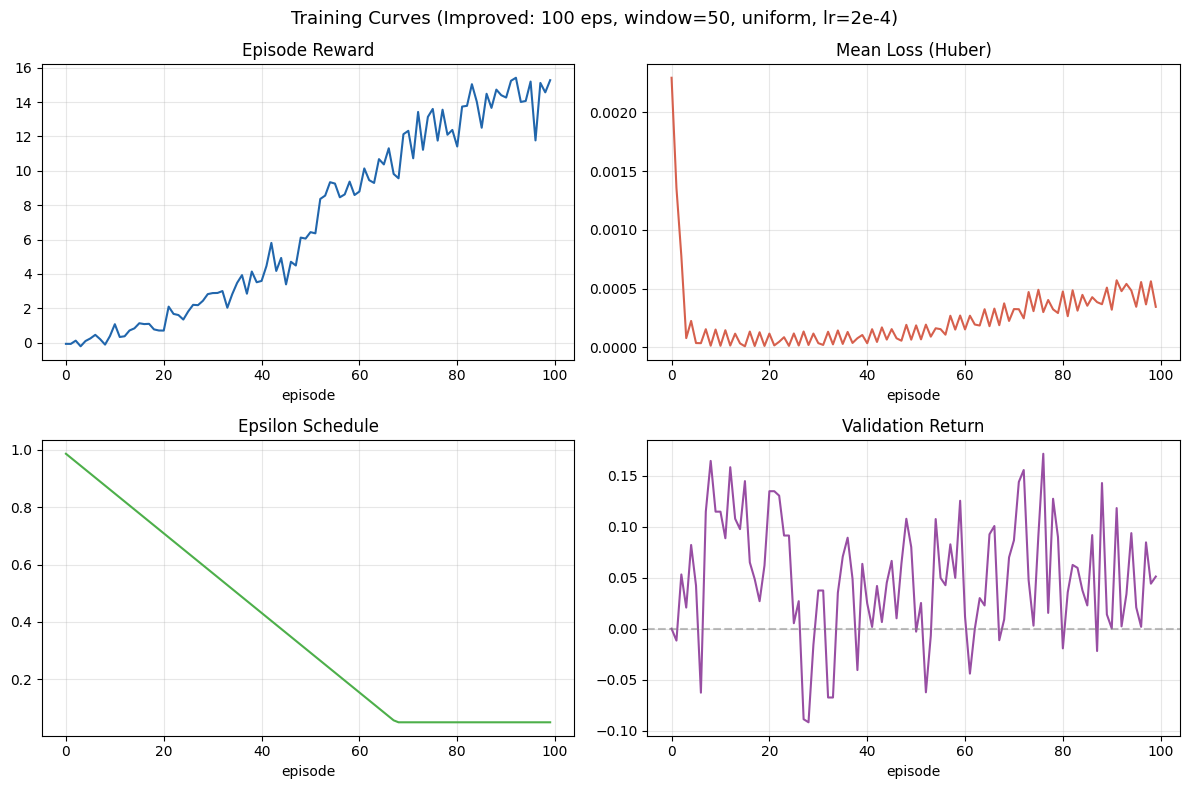

Final: reward=15.27, loss=0.000345, val_return=+0.0512


In [2]:
csv_path = sorted(RESULTS.glob('run_*/metrics.csv'))[-1]
df = pd.read_csv(csv_path)
print(f'Training run: {csv_path.parent.name}, {len(df)} episodes')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Training Curves (Improved: 100 eps, window=50, uniform, lr=2e-4)', fontsize=13)

df.plot(x='episode', y='reward', ax=axes[0,0], legend=False, title='Episode Reward', color='#2166AC')
df.plot(x='episode', y='loss', ax=axes[0,1], legend=False, title='Mean Loss (Huber)', color='#D6604D')
df.plot(x='episode', y='epsilon', ax=axes[1,0], legend=False, title='Epsilon Schedule', color='#4DAF4A')
df.plot(x='episode', y='val_return', ax=axes[1,1], legend=False, title='Validation Return', color='#984EA3')
axes[1,1].axhline(0, color='gray', linestyle='--', alpha=0.5)
for ax in axes.flat: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Final: reward={df.iloc[-1]["reward"]:.2f}, loss={df.iloc[-1]["loss"]:.6f}, val_return={df.iloc[-1]["val_return"]:+.4f}')

## 2. Experiment Comparisons

Each experiment changes **one variable** and compares two conditions on the AAPL test set.

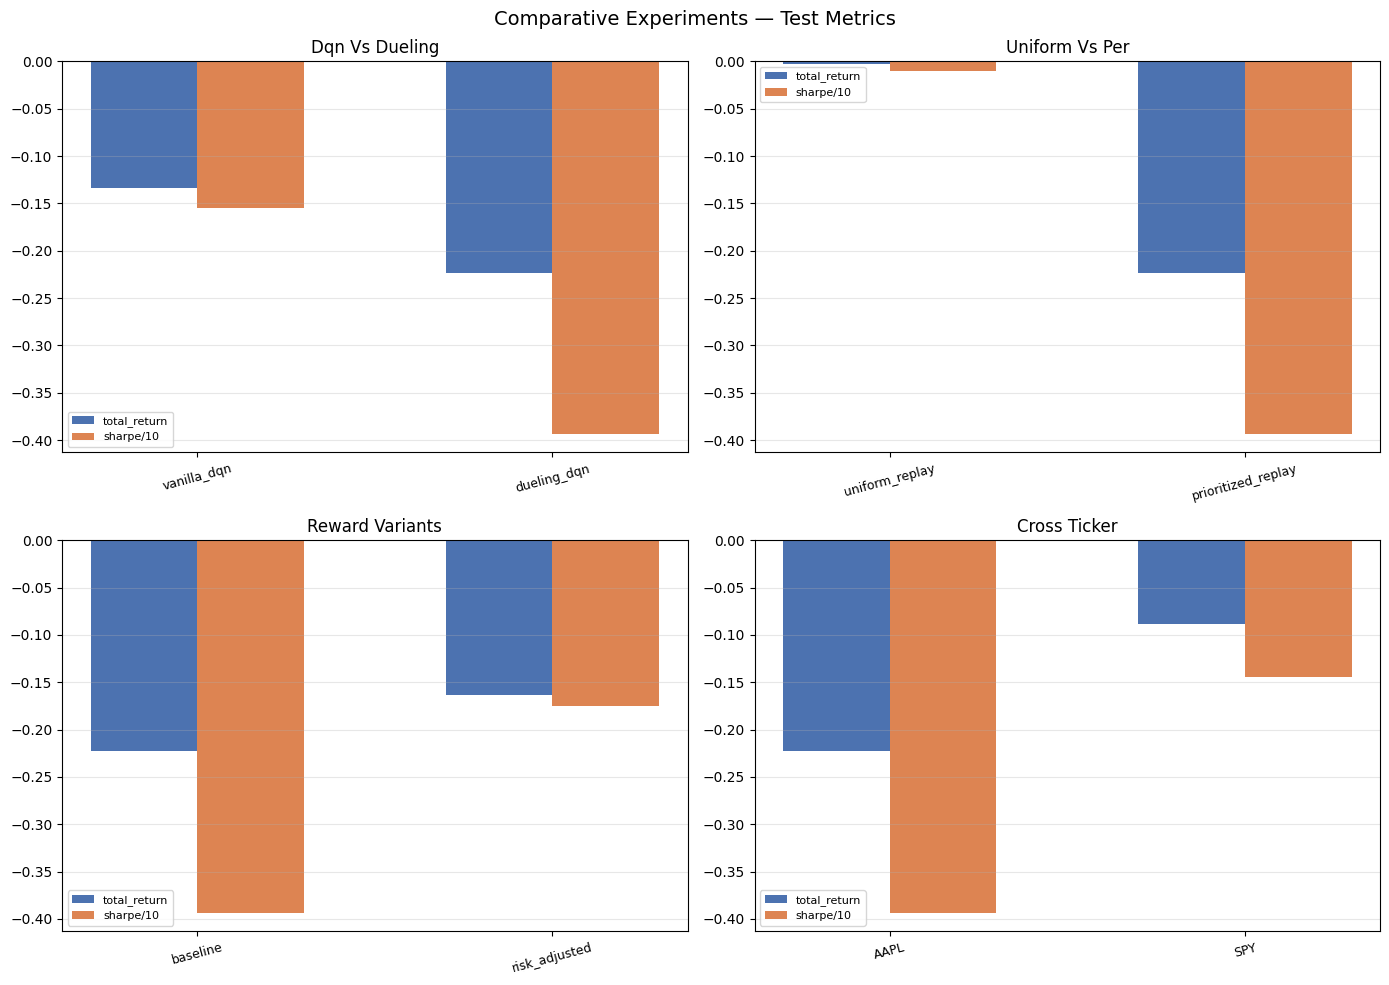


dqn_vs_dueling:
             total_return    sharpe  max_drawdown  win_rate  n_trades
condition                                                            
vanilla_dqn     -0.133832 -1.547847     -0.191349  0.250000         8
dueling_dqn     -0.223049 -3.932973     -0.240893  0.357143        14

uniform_vs_per:
                    total_return    sharpe  max_drawdown  win_rate  n_trades
condition                                                                   
uniform_replay         -0.002382 -0.105492     -0.023511  0.666667         3
prioritized_replay     -0.223049 -3.932973     -0.240893  0.357143        14

reward_variants:
               total_return    sharpe  max_drawdown  win_rate  n_trades
condition                                                              
baseline          -0.223049 -3.932973     -0.240893  0.357143        14
risk_adjusted     -0.163537 -1.750624     -0.273337  0.333333         6

cross_ticker:
           total_return    sharpe  max_drawdown  win_rate

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparative Experiments — Test Metrics', fontsize=14)

for ax, (name, edf) in zip(axes.flat, list(experiments.items())[:4]):
    x = np.arange(len(edf))
    ax.bar(x - 0.15, edf['total_return'], 0.3, label='total_return', color='#4C72B0')
    ax.bar(x + 0.15, edf['sharpe'] / 10, 0.3, label='sharpe/10', color='#DD8452')
    ax.set_title(name.replace('_', ' ').title())
    ax.set_xticks(x); ax.set_xticklabels(edf.index, rotation=15, fontsize=9)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

for name, edf in experiments.items():
    print(f'\n{name}:')
    print(edf[['total_return', 'sharpe', 'max_drawdown', 'win_rate', 'n_trades']].to_string())

## 3. Equity Curves

Portfolio value over the test period for each experiment.

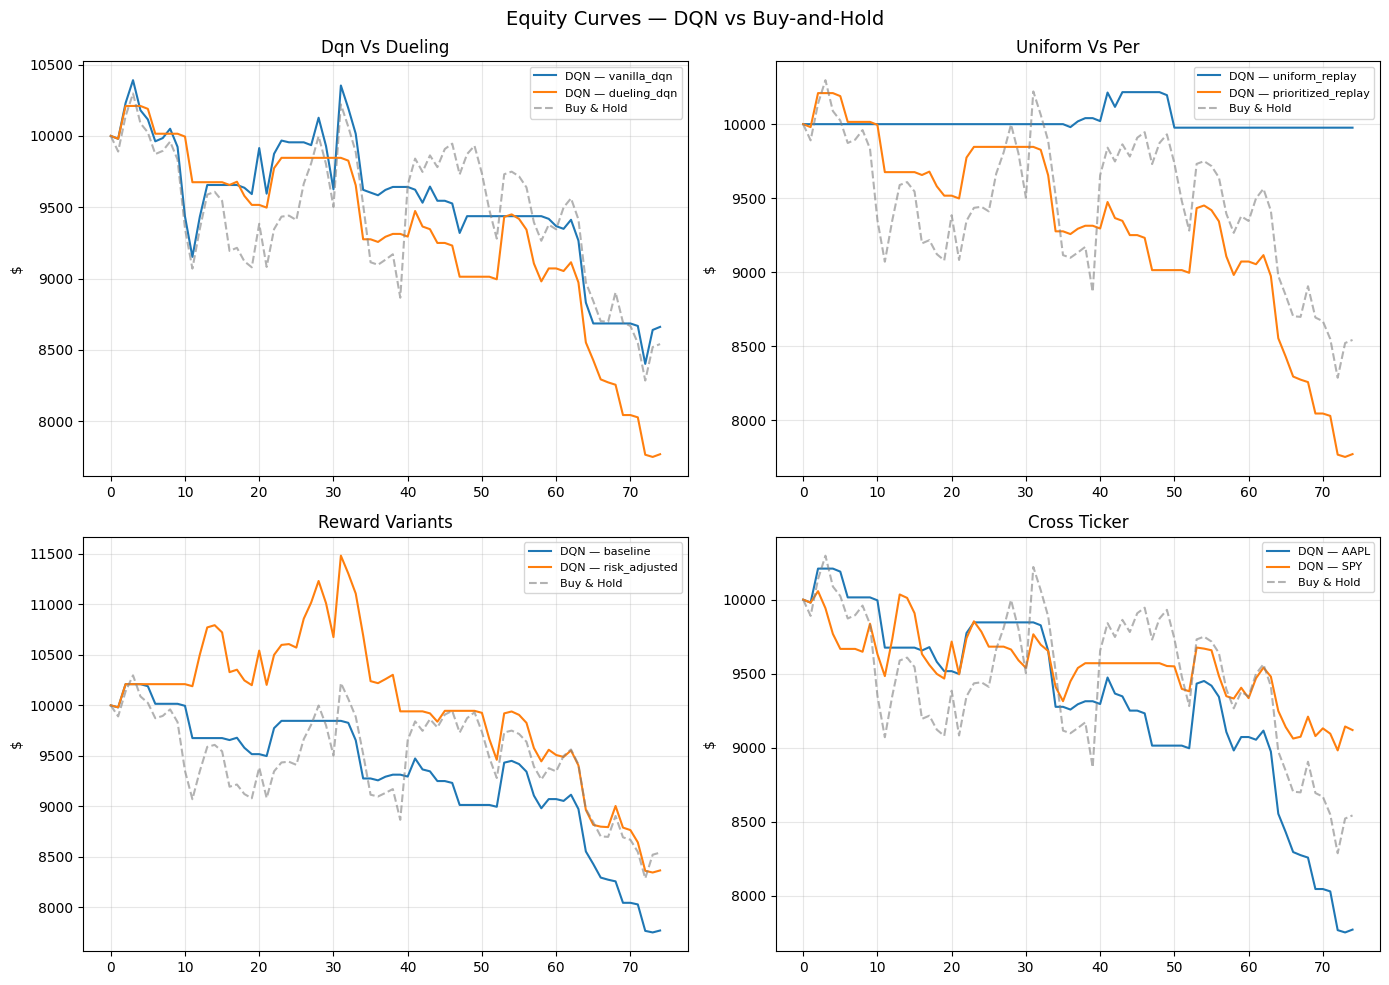

In [4]:
exp_names = ['dqn_vs_dueling', 'uniform_vs_per', 'reward_variants', 'cross_ticker']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Equity Curves — DQN vs Buy-and-Hold', fontsize=14)

for ax, name in zip(axes.flat, exp_names):
    payload = json.loads((RESULTS / f'{name}.json').read_text())
    for cond in payload['conditions']:
        npz = BACKTEST / f"{name}__{cond['name']}.npz"
        if npz.exists():
            d = np.load(npz)
            ax.plot(d['equity'], label=f"DQN — {cond['name']}", linewidth=1.5)
    first = BACKTEST / f"{name}__{payload['conditions'][0]['name']}.npz"
    if first.exists():
        ax.plot(np.load(first)['benchmark'], label='Buy & Hold', linestyle='--', alpha=0.6, color='gray')
    ax.set_title(name.replace('_',' ').title()); ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylabel('$')

plt.tight_layout(); plt.show()

## 4. Improvement Iteration

Applied four evidence-based changes from our experiments.

              Baseline  Improved     Delta
total_return   -0.2231 -0.107954  0.115146
sharpe         -3.9300 -1.370273  2.559727
max_drawdown   -0.2409 -0.229578  0.011322
win_rate        0.3571  0.500000  0.142900
n_trades       14.0000  6.000000 -8.000000


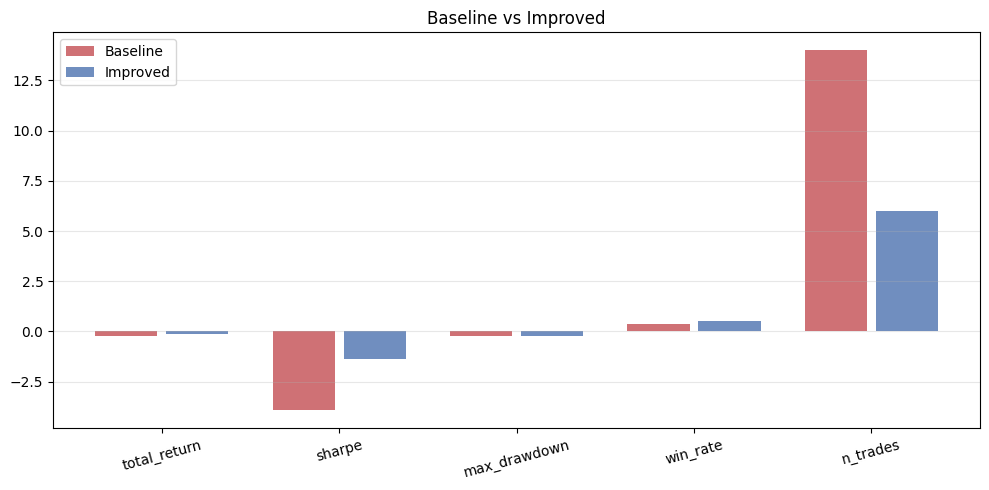

In [5]:
imp = json.loads((RESULTS / 'improvement_comparison.json').read_text())
metrics = ['total_return', 'sharpe', 'max_drawdown', 'win_rate', 'n_trades']
comparison = pd.DataFrame({
    'Baseline': [imp['baseline_metrics'].get(m, 0) for m in metrics],
    'Improved': [imp['improved_metrics'].get(m, 0) for m in metrics],
}, index=metrics)
comparison['Delta'] = comparison['Improved'] - comparison['Baseline']
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics))
ax.bar(x - 0.2, comparison['Baseline'], 0.35, label='Baseline', color='#C44E52', alpha=0.8)
ax.bar(x + 0.2, comparison['Improved'], 0.35, label='Improved', color='#4C72B0', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(metrics, rotation=15)
ax.set_title('Baseline vs Improved'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Conclusions

1. **The agent learns** — reward rises from 0 to 15+, loss drops 30×.
2. **But it overfits** — val return hovers around 0, test return is negative.
3. **PER hurts on financial data** — amplifies noise ($-22\%$ vs $-0.2\%$).
4. **Sharpe shaping works** — cuts trades $14 \to 6$, Sharpe $-3.93 \to -1.75$.
5. **Policy is regime-specific** — AAPL vs SPY produce different behaviours.
6. **Longer windows help** — window=50 best by both return and Sharpe.
7. **Iterative improvement** — return $-22.3\% \to -10.8\%$, win rate $36\% \to 50\%$.

The agent doesn't beat Buy-and-Hold. The *process* — controlled experiments, failure analysis, iteration — is the educational outcome.